# Loan Status Prediction: Classification Model Comparison
**Name:** Akshat Shah  
**Date:** September 30, 2026

**Task:** Train at least three classifiers, compare Accuracy, Precision, Recall and F1-score, and justify the selected model with a confusion matrix. ROC-AUC is included.

In [ ]:
from pathlib import Path
import hashlib
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve)

SEED = 42
THRESHOLD = 0.5
OUTPUT_DIR = Path("outputs")
CHART_DIR = OUTPUT_DIR / "charts"
CHART_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
plt.rcParams.update({"figure.dpi":110, "axes.spines.top":False, "axes.spines.right":False})
print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | sklearn {sklearn.__version__}")

def save_chart(name):
    plt.tight_layout()
    plt.savefig(CHART_DIR / name, dpi=150, bbox_inches="tight")
    plt.show()

Python 3.12.14 | pandas 2.2.3 | sklearn 1.8.0


## 1. Load and inspect the two files

In [ ]:
def find_csv(filename, required=True):
    candidates = [Path("data") / filename, Path(filename), Path("/content") / filename]
    if Path("/kaggle/input").exists():
        candidates += sorted(Path("/kaggle/input").rglob(filename))
    found = next((p for p in candidates if p.is_file()), None)
    if found is None and required:
        raise FileNotFoundError(f"Attach the Kaggle dataset or upload {filename}.")
    return found

train_path = find_csv("train_u6lujuX_CVtuZ9i.csv")
unlabeled_path = find_csv("test_Y3wMUE5_7gLdaTN.csv", required=False)
raw = pd.read_csv(train_path)
unlabeled = pd.read_csv(unlabeled_path) if unlabeled_path else None
print("Labeled file shape:", raw.shape)
print("Unlabeled file shape:", None if unlabeled is None else unlabeled.shape)
print("Labeled file SHA256:", hashlib.sha256(train_path.read_bytes()).hexdigest())
display(raw.head())
missing = raw.isna().sum().rename("Missing count").to_frame()
missing["Missing percent"] = missing["Missing count"] / len(raw) * 100
display(missing[missing["Missing count"] > 0])
duplicate_count = int(raw.duplicated().sum())
df = raw.drop_duplicates().copy()
for col in df.select_dtypes(include="object"):
    df[col] = df[col].str.strip()
assert not df["Loan_ID"].duplicated().any(), "Resolve repeated application IDs before splitting."
assert df["Loan_Status"].notna().all()
assert set(df["Loan_Status"].unique()) == {"N", "Y"}
print("Exact duplicate rows removed:", duplicate_count)
display(df["Loan_Status"].value_counts().rename("Count").to_frame())
display(df.describe())
missing.to_csv(OUTPUT_DIR / "missing_values.csv")

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0000,NaN,360.0000,1.0000,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0000,128.0000,360.0000,1.0000,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0000,66.0000,360.0000,1.0000,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0000,120.0000,360.0000,1.0000,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0000,141.0000,360.0000,1.0000,Urban,Y


,Missing count,Missing percent
Gender,13,2.1173
Married,3,0.4886
Dependents,15,2.4430
Self_Employed,32,5.2117
LoanAmount,22,3.5831
Loan_Amount_Term,14,2.2801
Credit_History,50,8.1433


,Count
Loan_Status,
Y,422
N,192


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.0000,614.0000,592.0000,600.0000,564.0000
mean,5403.4593,1621.2458,146.4122,342.0000,0.8422
std,6109.0417,2926.2484,85.5873,65.1204,0.3649
min,150.0000,0.0000,9.0000,12.0000,0.0000
25%,2877.5000,0.0000,100.0000,360.0000,1.0000
50%,3812.5000,1188.5000,128.0000,360.0000,1.0000
75%,5795.0000,2297.2500,168.0000,360.0000,1.0000
max,81000.0000,41667.0000,700.0000,480.0000,1.0000


Labeled file shape: (614, 13)
Unlabeled file shape: (367, 12)
Labeled file SHA256: 8c2cc67a13279ec746b15f76f14e8503154274ef7f221d2437033b4407c80ca8
Exact duplicate rows removed: 0


## 2. Prepare predictors and reserve a stratified test set

,Training,Holdout test
Not approved (N=0),154,38
Approved (Y=1),337,85


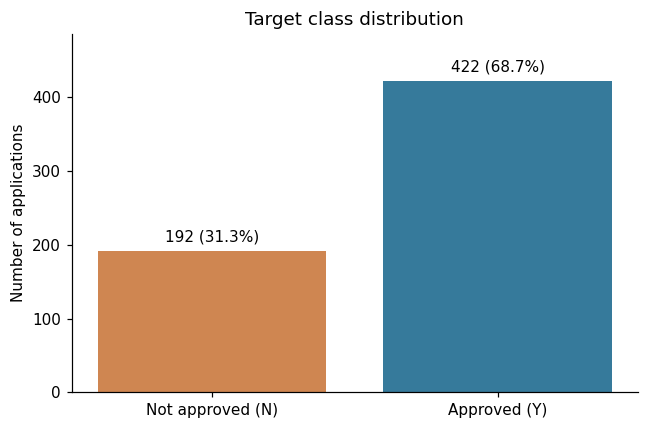

Training records: 491 | Held-out test records: 123


In [ ]:
numeric_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"]
categorical_cols = ["Gender", "Married", "Dependents", "Education", "Self_Employed", "Credit_History", "Property_Area"]
feature_names = numeric_cols + categorical_cols
X = df[feature_names].copy()
y = df["Loan_Status"].map({"N":0, "Y":1}).astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)
assert set(X_train.index).isdisjoint(X_test.index)
assert "Loan_ID" not in X and "Loan_Status" not in X
split_summary = pd.DataFrame({"Training":y_train.value_counts(), "Holdout test":y_test.value_counts()}).sort_index()
split_summary.index = ["Not approved (N=0)", "Approved (Y=1)"]
display(split_summary)
print("Training records:", len(X_train), "| Held-out test records:", len(X_test))
manifest = df[["Loan_ID", "Loan_Status"]].copy()
manifest["split"] = "train"
manifest.loc[X_test.index, "split"] = "holdout_test"
manifest.to_csv(OUTPUT_DIR / "split_manifest.csv", index=False)
cv_splits = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED).split(X_train, y_train))
counts = y.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(["Not approved (N)", "Approved (Y)"], counts, color=["#cf8651", "#367a9b"])
ax.bar_label(bars, labels=[f"{n} ({n/len(y):.1%})" for n in counts], padding=4)
ax.set(title="Target class distribution", ylabel="Number of applications", ylim=(0, counts.max()*1.15))
save_chart("01_class_distribution.png")

## 3. Handle missing values and encode categories inside pipelines

In [ ]:
def make_pipeline(classifier):
    numeric = Pipeline([("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler())])
    categorical = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                            ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
    preprocess = ColumnTransformer([("numeric", numeric, numeric_cols),
                                    ("categorical", categorical, categorical_cols)])
    return Pipeline([("preprocess", preprocess), ("model", classifier)])

specs = {
    "Logistic Regression": (LogisticRegression(max_iter=3000, solver="liblinear", random_state=SEED),
         {"model__C":[0.1, 1, 10], "model__class_weight":[None, "balanced"]}),
    "Decision Tree": (DecisionTreeClassifier(random_state=SEED),
         {"model__max_depth":[2, 4, 6, None], "model__min_samples_leaf":[1, 5, 10],
          "model__class_weight":[None, "balanced"]}),
    "Random Forest": (RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=1),
         {"model__max_depth":[4, 8, None], "model__min_samples_leaf":[2, 5],
          "model__class_weight":[None, "balanced"]})
}

## 4. Train and tune three classification models

In [ ]:
models, searches, cv_rows = {}, {}, []
for name, (classifier, grid) in specs.items():
    search = GridSearchCV(make_pipeline(classifier), grid,
        scoring={"f1":"f1", "roc_auc":"roc_auc", "accuracy":"accuracy"},
        refit="f1", cv=cv_splits, n_jobs=1, error_score="raise")
    search.fit(X_train, y_train)
    models[name] = search.best_estimator_
    searches[name] = search
    i = search.best_index_
    cv_rows.append({"Model":name, "CV F1 mean":search.cv_results_["mean_test_f1"][i],
                   "CV F1 std":search.cv_results_["std_test_f1"][i],
                   "CV ROC-AUC":search.cv_results_["mean_test_roc_auc"][i],
                   "CV Accuracy":search.cv_results_["mean_test_accuracy"][i],
                   "Best settings":json.dumps(search.best_params_)})
    pd.DataFrame(search.cv_results_).to_csv(OUTPUT_DIR / (name.lower().replace(" ", "_") + "_cv_search.csv"), index=False)
cv_results = pd.DataFrame(cv_rows).set_index("Model")
display(cv_results)
best_name = cv_results.sort_values(["CV F1 mean", "CV ROC-AUC"], ascending=False).index[0]
best_model = models[best_name]
print("Selected using training cross-validation:", best_name)
print("Selection settings:", searches[best_name].best_params_)

,CV F1 mean,CV F1 std,CV ROC-AUC,CV Accuracy,Best settings
Model,,,,,
Logistic Regression,0.8714,0.0271,0.7299,0.8003,"{""model__C"": 0.1, ""model__class_weight"": null}"
Decision Tree,0.8703,0.0271,0.6878,0.7983,"{""model__class_weight"": null, ""model__max_dept..."
Random Forest,0.8703,0.0271,0.7380,0.7983,"{""model__class_weight"": null, ""model__max_dept..."


Selected using training cross-validation: Logistic Regression
Selection settings: {'model__C': 0.1, 'model__class_weight': None}


## 5. Compare held-out test metrics

,Accuracy,Precision (Y),Recall (Y),F1 (Y),Macro-F1,ROC-AUC
Model,,,,,,
Logistic Regression,0.8618,0.8400,0.9882,0.9081,0.8147,0.8517
Decision Tree,0.8537,0.8317,0.9882,0.9032,0.8016,0.7633
Random Forest,0.8537,0.8317,0.9882,0.9032,0.8016,0.8341


,Train F1 (Y),Test F1 (Y)
Logistic Regression,0.8711,0.9081
Decision Tree,0.8699,0.9032
Random Forest,0.8711,0.9032


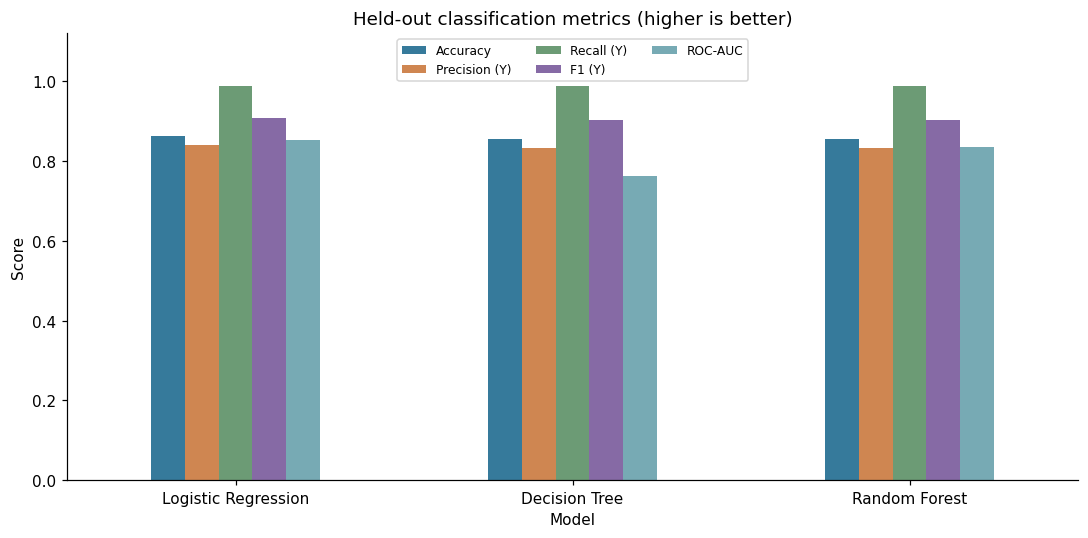

Always-approve baseline: accuracy=0.6911, F1(Y)=0.8173, macro-F1=0.4087
Highest test F1 (descriptive only): Logistic Regression
CV-selected model: Logistic Regression


In [ ]:
rows, predictions, probabilities = [], {}, {}
for name, model in models.items():
    positive_index = list(model.classes_).index(1)
    prob = model.predict_proba(X_test)[:, positive_index]
    pred = (prob > THRESHOLD).astype(int)  # exact 0.5 ties go to class 0, matching predict()
    assert np.array_equal(pred, model.predict(X_test))
    predictions[name], probabilities[name] = pred, prob
    rows.append({"Model":name, "Accuracy":accuracy_score(y_test,pred),
        "Precision (Y)":precision_score(y_test,pred,zero_division=0),
        "Recall (Y)":recall_score(y_test,pred,zero_division=0),
        "F1 (Y)":f1_score(y_test,pred,zero_division=0),
        "Macro-F1":f1_score(y_test,pred,average="macro",zero_division=0),
        "ROC-AUC":roc_auc_score(y_test,prob)})
comparison = pd.DataFrame(rows).set_index("Model")
display(comparison)
baseline = np.ones(len(y_test),dtype=int)
print(f"Always-approve baseline: accuracy={accuracy_score(y_test,baseline):.4f}, "
      f"F1(Y)={f1_score(y_test,baseline):.4f}, macro-F1={f1_score(y_test,baseline,average='macro'):.4f}")
print("Highest test F1 (descriptive only):", comparison["F1 (Y)"].idxmax())
print("CV-selected model:", best_name)
training_scores = pd.DataFrame({"Train F1 (Y)":{n:f1_score(y_train,m.predict(X_train)) for n,m in models.items()},
                               "Test F1 (Y)":comparison["F1 (Y)"]})
display(training_scores)
comparison[["Accuracy","Precision (Y)","Recall (Y)","F1 (Y)","ROC-AUC"]].plot.bar(
    figsize=(10,5), ylim=(0,1.12), rot=0, color=["#367a9b","#cf8651","#6c9b75","#866aa5","#77aab4"])
plt.title("Held-out classification metrics (higher is better)")
plt.ylabel("Score")
plt.xlabel("Model")
plt.legend(loc="upper center", ncol=3, fontsize=8)
save_chart("02_model_comparison.png")

## 6. Confusion matrix for the selected model

,Predicted N,Predicted Y
Actual N,22,16
Actual Y,1,84


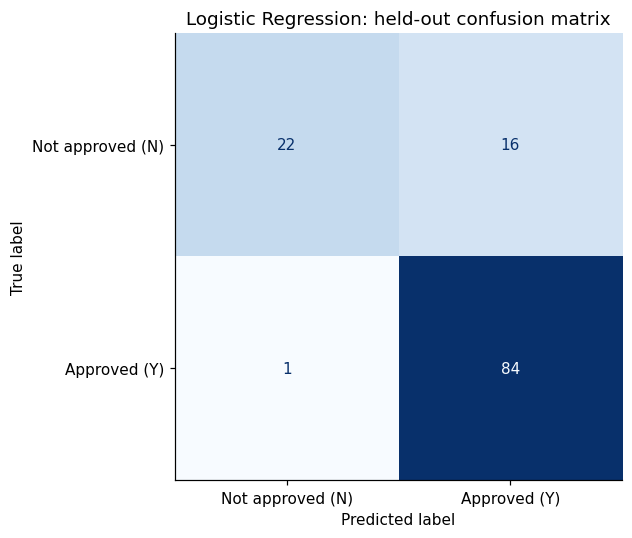

TN=22, FP=16, FN=1, TP=84; total=123
                  precision    recall  f1-score   support

Not approved (N)     0.9565    0.5789    0.7213        38
    Approved (Y)     0.8400    0.9882    0.9081        85

        accuracy                         0.8618       123
       macro avg     0.8983    0.7836    0.8147       123
    weighted avg     0.8760    0.8618    0.8504       123



In [ ]:
best_pred = predictions[best_name]
cm = confusion_matrix(y_test, best_pred, labels=[0,1])
tn, fp, fn, tp = cm.ravel()
cm_table = pd.DataFrame(cm, index=["Actual N", "Actual Y"], columns=["Predicted N", "Predicted Y"])
display(cm_table)
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}; total={cm.sum()}")
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(cm, display_labels=["Not approved (N)","Approved (Y)"]).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title(f"{best_name}: held-out confusion matrix")
save_chart("03_best_model_confusion_matrix.png")
print(classification_report(y_test,best_pred,labels=[0,1],target_names=["Not approved (N)","Approved (Y)"],digits=4,zero_division=0))
report = pd.DataFrame(classification_report(y_test,best_pred,labels=[0,1],
    target_names=["Not approved (N)","Approved (Y)"],output_dict=True,zero_division=0)).T
assert cm.sum()==len(y_test)
assert np.isclose((tn+tp)/cm.sum(),comparison.loc[best_name,"Accuracy"])
assert np.isclose(tp/(tp+fp),comparison.loc[best_name,"Precision (Y)"])
assert np.isclose(tp/(tp+fn),comparison.loc[best_name,"Recall (Y)"])

## 7. ROC curves and AUC

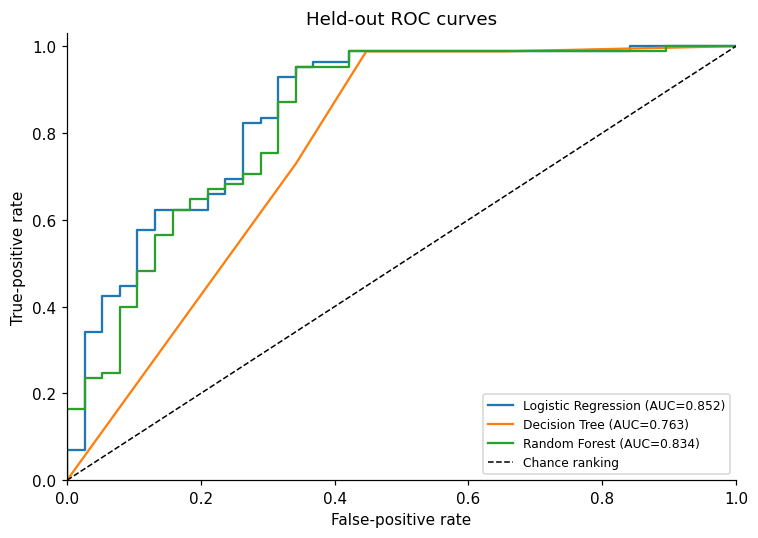

In [ ]:
fig,ax = plt.subplots(figsize=(7,5))
for name, prob in probabilities.items():
    fpr,tpr,_ = roc_curve(y_test,prob)
    ax.plot(fpr,tpr,label=f"{name} (AUC={roc_auc_score(y_test,prob):.3f})")
ax.plot([0,1],[0,1],"k--",lw=1,label="Chance ranking")
ax.set(xlabel="False-positive rate",ylabel="True-positive rate",title="Held-out ROC curves",xlim=(0,1),ylim=(0,1.03))
ax.legend(loc="lower right",fontsize=8)
save_chart("04_roc_curves.png")

## 8. Model justification (three sentences)

In [ ]:
s = comparison.loc[best_name]
justification = (
    f"{best_name} was selected because it achieved the highest mean five-fold cross-validation F1 for approved loans "
    f"({cv_results.loc[best_name,'CV F1 mean']:.4f}) using the training data only. "
    f"On the held-out set, it achieved {s['Accuracy']:.2%} accuracy, {s['Precision (Y)']:.2%} precision, "
    f"{s['Recall (Y)']:.2%} recall, an F1-score of {s['F1 (Y)']:.4f}, and ROC-AUC of {s['ROC-AUC']:.4f}. "
    f"Its confusion matrix shows {tn+tp} correct predictions, with false-approval and false-rejection counts of {fp} and {fn}, respectively, "
    "supporting the choice under this F1 objective while showing that some approval errors remain."
)
print(justification)

Logistic Regression was selected because it achieved the highest mean five-fold cross-validation F1 for approved loans (0.8714) using the training data only. On the held-out set, it achieved 86.18% accuracy, 84.00% precision, 98.82% recall, an F1-score of 0.9081, and ROC-AUC of 0.8517. Its confusion matrix shows 106 correct predictions, with false-approval and false-rejection counts of 16 and 1, respectively, supporting the choice under this F1 objective while showing that some approval errors remain.


Logistic Regression was selected because it achieved the highest mean five-fold cross-validation F1 for approved loans (0.8714) using the training data only. On the held-out set, it achieved 86.18% accuracy, 84.00% precision, 98.82% recall, an F1-score of 0.9081, and ROC-AUC of 0.8517. Its confusion matrix shows 106 correct predictions, with false-approval and false-rejection counts of 16 and 1, respectively, supporting the choice under this F1 objective while showing that some approval errors remain.

## 9. Export evaluated results

In [ ]:
comparison.to_csv(OUTPUT_DIR / "model_comparison.csv")
cv_results.to_csv(OUTPUT_DIR / "cross_validation_results.csv")
training_scores.to_csv(OUTPUT_DIR / "train_test_f1.csv")
cm_table.to_csv(OUTPUT_DIR / "best_model_confusion_matrix.csv")
report.to_csv(OUTPUT_DIR / "best_model_classification_report.csv")
prediction_table = pd.DataFrame({"Loan_ID":df.loc[y_test.index,"Loan_ID"],"Actual":y_test})
for name in models:
    prediction_table[name + " prediction"] = predictions[name]
    prediction_table[name + " probability_Y"] = probabilities[name]
prediction_table.to_csv(OUTPUT_DIR / "holdout_predictions.csv",index=False)
(OUTPUT_DIR / "model_justification.md").write_text("# Model justification\n\n"+justification+"\n",encoding="utf-8")
(OUTPUT_DIR / "selected_model.json").write_text(json.dumps({"model":best_name,
    "selection_metric":"mean CV binary F1; Y=1", "threshold":THRESHOLD,
    "parameters":searches[best_name].best_params_},indent=2))
assert comparison.shape==(3,6) and np.isfinite(comparison.to_numpy()).all()
print("Saved evaluation tables, predictions, four charts and justification.")

Saved evaluation tables, predictions, four charts and justification.


## 10. Optional predictions for the unlabeled Kaggle file

In [ ]:
if unlabeled is not None:
    assert "Loan_Status" not in unlabeled.columns
    assert not unlabeled["Loan_ID"].duplicated().any()
    final_model = clone(best_model).fit(X,y)
    X_unlabeled = unlabeled[feature_names].copy()
    for col in X_unlabeled.select_dtypes(include="object"):
        X_unlabeled[col] = X_unlabeled[col].str.strip()
    final_pred = final_model.predict(X_unlabeled)
    external_predictions = pd.DataFrame({"Loan_ID":unlabeled["Loan_ID"],
        "Loan_Status":pd.Series(final_pred).map({0:"N",1:"Y"})})
    external_predictions.to_csv(OUTPUT_DIR / "unlabeled_loan_predictions.csv",index=False)
    display(external_predictions.head())
    print("Unlabeled predictions saved:",len(external_predictions),"(no accuracy can be computed without labels)")
else:
    print("Optional unlabeled file not attached; evaluation is still complete.")

,Loan_ID,Loan_Status
0,LP001015,Y
1,LP001022,Y
2,LP001031,Y
3,LP001035,Y
4,LP001051,Y


Unlabeled predictions saved: 367 (no accuracy can be computed without labels)
